[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Arquivo lido com sucesso!
Colunas encontradas: ['DATA', 'SITE', 'LOCAL', 'Fonte', 'Origem', 'Área', 'Motivo', 'Menção', 'Reclamação/Elogio', 'Elogios', 'Contagem', 'BU', 'Codigo', 'mês', 'semestre', 'ano', 'BU Classficiação', 'Sub-Motivo', 'Semantica isolada', 'Pilar']

=== RESULTADO FINAL ===
Menção à Pragas: 2037
Reclamação de Manutencao: 3249
Ameaça de processo: 178
Comparações e concorrencial: 230
DV: 173
Casos de furto: 94
Casos de racismo: 6
Menção de propaganda: 52


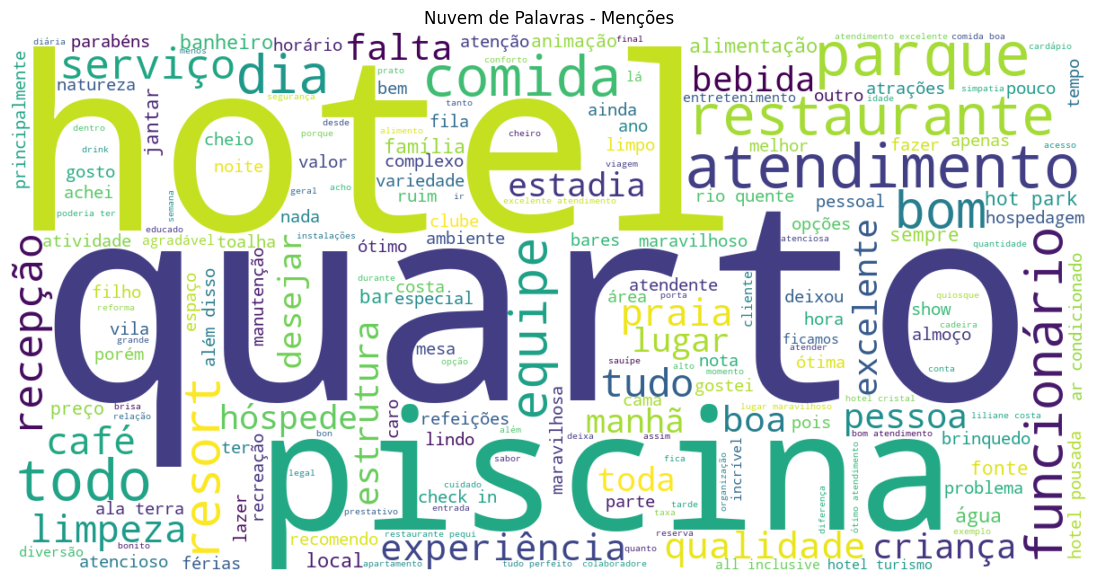

In [7]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# ============================================================
# 1. Chamando a Tabela fato
# ============================================================

try:
    df = pd.read_excel("Tabela_fato_Pesquisas.xlsx")
    print("✅ Arquivo lido com sucesso!")
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Verifique o nome e se está na mesma pasta do notebook.")
except PermissionError:
    print("❌ Permissão negada. Feche o arquivo no Excel e tente novamente.")

# ============================================================
# 2. Normalização da tabela fato
# ============================================================

# Verificar nomes das colunas
print("Colunas encontradas:", df.columns.tolist())

# Normalizar texto da coluna 'Menção'
df['Menção'] = df['Menção'].fillna("").astype(str).str.lower()

# Converter coluna de data
df['DATA'] = pd.to_datetime(df['DATA'], errors='coerce')

# Criar colunas de ano e mês
df['Ano'] = df['DATA'].dt.year
df['Mes'] = df['DATA'].dt.month

# ============================================================
# 3. Dicionário de categorizações
# ============================================================

categorias = {
    "Menção à Pragas": ["barata","baratas","pombo","pombos","rato","ratos","larva","larvas","aranha","aranhas"],
    "Reclamação de Manutencao": ["manutenção","manutenções","obra","obras","interditado","barulho de obra","construção"],
    "Ameaça de processo": ["processar","processando","direitos","advogado","justiça","processo"],
    "Comparações e concorrencial": ["tauá","olímpia","olimpia","taua","roma","lagoa","concorrentes"],
    "DV": ["diarreia","diarréia","vômito","vomito","intoxicação","passando mal","segurança alimentar"],
    "Casos de furto": ["roubo","roubaram","furto","furtaram","roubar"],
    "Casos de racismo": ["racismo","cor da pele","racista","preconceituoso","preconceituosa"],
    "Menção de propaganda": ["propaganda enganosa","anúncio enganoso"]
}

# ============================================================
# 4. Ensinando o código a contar ocorrências
# ============================================================

def contar_categoria(texto, palavras):
    return any(p in texto for p in palavras)

for nome_cat, palavras in categorias.items():
    df[nome_cat] = df['Menção'].apply(lambda x: contar_categoria(x, palavras))

# ============================================================
# 5. Aplicando contexto de filtro
# ============================================================

def filtrar(mes, ano):
    return df[(df['Mes'] == mes) & (df['Ano'] == ano)]

# Exemplo de filtro
df_filtrado = df[df['Ano'].isin([2024, 2025])]

# ============================================================
# 6. Ensinando contagem final
# ============================================================

resultado = {cat: df_filtrado[cat].sum() for cat in categorias.keys()}

print("\n=== RESULTADO FINAL ===")
for cat, qtd in resultado.items():
    print(f"{cat}: {qtd}")

# ============================================================
# 7. Ensinando o código a ler erros na Word cloud e reparar retornando valor válido
# ============================================================

texto_completo = " ".join(df_filtrado['Menção'])

if texto_completo.strip():  # Verifica se há conteúdo
    stopwords_pt = set(stopwords.words('portuguese'))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords_pt
).generate(texto_completo)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuvem de Palavras - Menções")
plt.show()

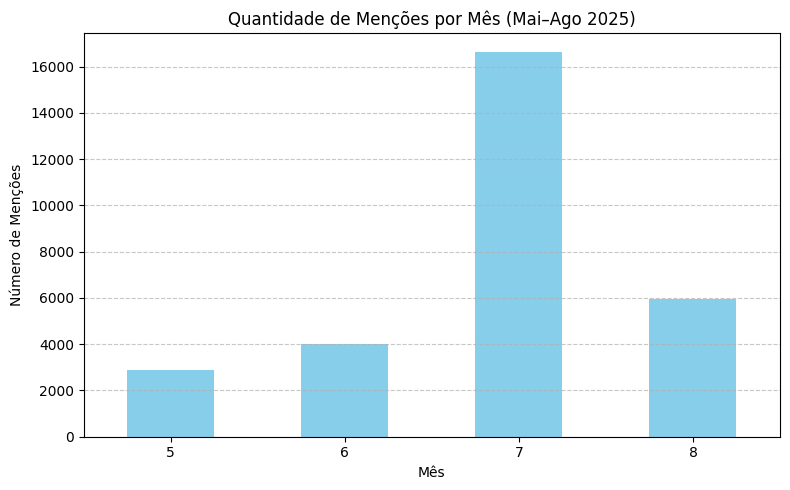

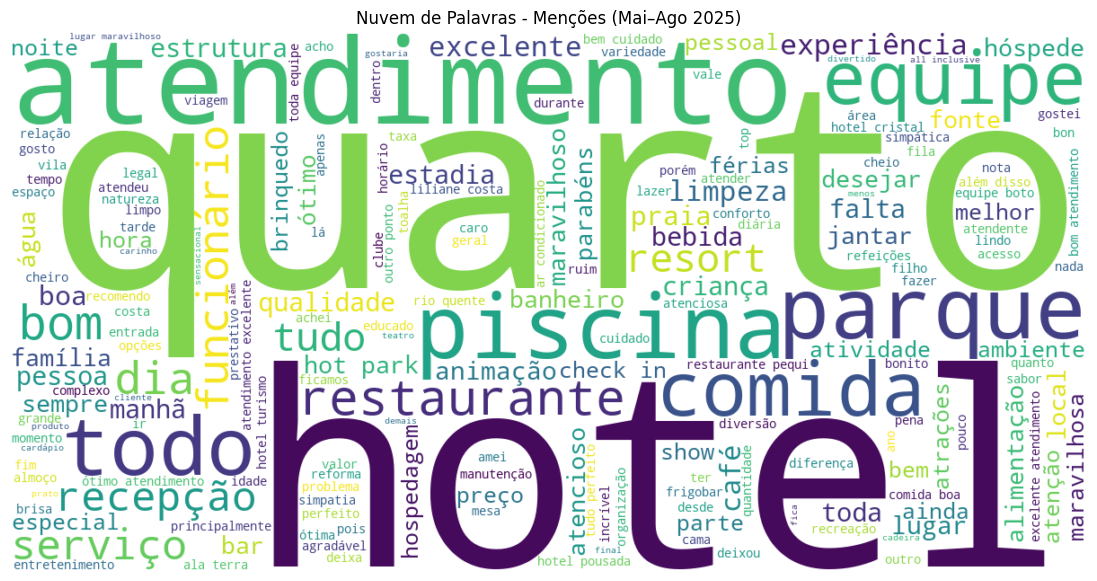

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

# -----------------------------
# 1. Filtrar dados de maio a agosto de 2025
# -----------------------------
df_periodo = df[(df['Ano'] == 2025) & (df['Mes'].isin([5, 6, 7, 8]))]

# -----------------------------
# 2. Contar menções por mês
# -----------------------------
contagem_mensal = df_periodo.groupby('Mes')['Menção'].count().sort_index()

# -----------------------------
# 3. Gráfico de barras
# -----------------------------
plt.figure(figsize=(8,5))
contagem_mensal.plot(kind='bar', color='skyblue')
plt.title("Quantidade de Menções por Mês (Mai–Ago 2025)")
plt.xlabel("Mês")
plt.ylabel("Número de Menções")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# 4. WordCloud das menções
# -----------------------------
texto_periodo = " ".join(df_periodo['Menção'])

if texto_periodo.strip():
    stopwords_pt = set(stopwords.words('portuguese'))

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stopwords_pt
    ).generate(texto_periodo)

    plt.figure(figsize=(14,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Nuvem de Palavras - Menções (Mai–Ago 2025)")
    plt.show()
else:
    print("⚠️ Nenhuma menção encontrada para esse período.")
